# Course Project: Movie Revenue and Popularity Analysis


## How to run this notebook

1. Install required Python packages:
   pip install pandas matplotlib seaborn requests

2. Install Ollama (for the LLM API component):
   Download from: https://ollama.com

3. Run a local model in Ollama ollama run gemma3:1b

4. Place the datasets in the same folder as project.ipynb:
   - tmdb_5000_movies.csv
   - tmdb_5000_credits.csv

   The datasets can be downloaded from:
   https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata

5. Run all cells from top to bottom in the notebook

## AI Usage Statement
I used ChatGPT to help with debugging. All code and analysis were written and understood by me.

## Introduction

The goal of this project is to analyze what factors influence movie revenue and popularity.

Specifically, I want to investigate:
- How budget affects revenue
- Which genres are most profitable
- Whether ratings are related to revenue

The dataset used is the TMDB 5000 Movie Dataset from Kaggle.

## Data Pipeline Overview

![Data Pipeline](pipeline.png)

## Data Loading and Raw Data Export


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv

movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")

movies = movies.merge(credits, on="title")

movies.head()


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


## Data Cleaning and Transformation


In [2]:
movies = movies[[
    "title",
    "genres",
    "keywords",
    "cast",
    "crew",
    "budget",
    "revenue",
    "popularity",
    "vote_average",
    "vote_count",
    "overview"
]]

movies.head()

,title,genres,keywords,cast,crew,budget,revenue,popularity,vote_average,vote_count,overview
0,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",237000000,2787965087,150.437577,7.2,11800,"In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",300000000,961000000,139.082615,6.9,4500,"Captain Barbossa, long believed to be dead, ha..."
2,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",245000000,880674609,107.376788,6.3,4466,A cryptic message from Bond’s past sends him o...
3,The Dark Knight Rises,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",250000000,1084939099,112.312950,7.6,9106,Following the death of District Attorney Harve...
4,John Carter,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",260000000,284139100,43.926995,6.1,2124,"John Carter is a war-weary, former military ca..."


In [3]:
movies.isnull().sum()

title           0
genres          0
keywords        0
cast            0
crew            0
budget          0
revenue         0
popularity      0
vote_average    0
vote_count      0
overview        3
dtype: int64

In [4]:
movies = movies.dropna()

In [5]:
import ast

def convert(text):
    return [i["name"] for i in ast.literal_eval(text)]

def convert3(text):
    return [i["name"] for i in ast.literal_eval(text)[:3]]

def fetch_director(text):
    for i in ast.literal_eval(text):
        if i["job"] == "Director":
            return [i["name"]]
    return []

In [6]:
movies["genres"] = movies["genres"].apply(convert)
movies["keywords"] = movies["keywords"].apply(convert)
movies["cast"] = movies["cast"].apply(convert3)
movies["crew"] = movies["crew"].apply(fetch_director)

movies.head()

,title,genres,keywords,cast,crew,budget,revenue,popularity,vote_average,vote_count,overview
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron],237000000,2787965087,150.437577,7.2,11800,"In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski],300000000,961000000,139.082615,6.9,4500,"Captain Barbossa, long believed to be dead, ha..."
2,Spectre,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes],245000000,880674609,107.376788,6.3,4466,A cryptic message from Bond’s past sends him o...
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan],250000000,1084939099,112.312950,7.6,9106,Following the death of District Attorney Harve...
4,John Carter,"[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton],260000000,284139100,43.926995,6.1,2124,"John Carter is a war-weary, former military ca..."


In [7]:
movies = movies[(movies["budget"] > 0) & (movies["revenue"] > 0)]

movies.shape

(3232, 11)

In [8]:
movies["main_genre"] = movies["genres"].apply(
    lambda x: x[0] if len(x) > 0 else "Unknown"
)

movies[["title", "main_genre"]].head()

,title,main_genre
0,Avatar,Action
1,Pirates of the Caribbean: At World's End,Adventure
2,Spectre,Action
3,The Dark Knight Rises,Action
4,John Carter,Action


In [9]:
movies["profit"] = movies["revenue"] - movies["budget"]
movies["roi"] = movies["profit"] / movies["budget"]

movies[["title", "budget", "revenue", "profit", "roi"]].head()

,title,budget,revenue,profit,roi
0,Avatar,237000000,2787965087,2550965087,10.763566
1,Pirates of the Caribbean: At World's End,300000000,961000000,661000000,2.203333
2,Spectre,245000000,880674609,635674609,2.594590
3,The Dark Knight Rises,250000000,1084939099,834939099,3.339756
4,John Carter,260000000,284139100,24139100,0.092843


In [10]:
movies["tags"] = movies["genres"] + movies["keywords"] + movies["cast"] + movies["crew"]
movies["tags"] = movies["tags"].apply(lambda x: " ".join(x))

movies[["title", "tags"]].head()

,title,tags
0,Avatar,Action Adventure Fantasy Science Fiction cultu...
1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action ocean drug abuse exot...
2,Spectre,Action Adventure Crime spy based on novel secr...
3,The Dark Knight Rises,Action Crime Drama Thriller dc comics crime fi...
4,John Carter,Action Adventure Science Fiction based on nove...


In [11]:
movies_clean = movies.copy()

In [12]:
### The data was cleaned by selecting relevant columns, removing missing values, and removing movies with zero budget or zero revenue. JSON-like columns such as genres, keywords, cast and crew were transformed into readable lists. The top three cast members were extracted, and the director was extracted from the crew column. New variables such as main genre, profit, ROI, and tags were created for further analysis.

## API Component: LLM-based Movie Description Classification


### This section uses Ollama as a local LLM API. The model analyzes movie overview texts and classifies them into broad genre categories. Since Ollama runs locally, no API key is needed.

In [13]:
import requests

def classify_movie_overview(overview, model="gemma3:1b"):
    prompt = f"""
Classifying the following movie overview into exactly one category:

Action, Comedy, Drama, Romance, Science Fiction, Horror, Other

Returning only the category name. Do not explain.

Movie overview:
{overview}
"""

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": model,
            "prompt": prompt,
            "stream": False
        }
    )

    result = response.json()["response"].strip()

    valid_categories = [
        "Action", "Comedy", "Drama", "Romance",
        "Science Fiction", "Horror", "Other"
    ]

    for category in valid_categories:
        if category.lower() in result.lower():
            return category

    return "Other"

In [14]:
classify_movie_overview(movies["overview"].iloc[0])

'Science Fiction'

In [15]:
movie_sample = movies.sample(10, random_state=42).copy()

movie_sample["llm_genre"] = movie_sample["overview"].apply(classify_movie_overview)

movie_sample[["title", "overview", "main_genre", "llm_genre"]]

,title,overview,main_genre,llm_genre
3681,Hostel,Three backpackers head to a Slovakian city tha...,Horror,Horror
4359,The Green Inferno,A group of student activists travel from New Y...,Action,Horror
3871,City of God,Cidade de Deus is a shantytown that started du...,Drama,Other
30,Spider-Man 2,Peter Parker is going through a major identity...,Action,Comedy
141,Mars Needs Moms,"When Martians suddenly abduct his mom, mischie...",Adventure,Comedy
400,Divergent,In a world divided into factions based on pers...,Adventure,Action
655,Red Dawn,"It is the mid-1980s. From out of the sky, Sovi...",Action,Horror
259,Speed 2: Cruise Control,Sandra Bullock and Jason Patric star as a youn...,Action,Horror
2318,Legally Blonde,Elle Woods has it all. She's the president of ...,Comedy,Romance
2718,Flipped,"When Juli meets Bryce in the second grade, she...",Romance,Romance


In [16]:
import os

os.makedirs("exports", exist_ok=True)
movie_sample.to_csv("exports/llm_movie_classifications.csv", index=False)


## Visual and Quantitative Analysis


### In this section, the cleaned movie dataset is analyzed using both visualizations and summary statistics. The goal is to explore relationships between variables such as budget, revenue, popularity, and genres, and to identify patterns that influence movie success.

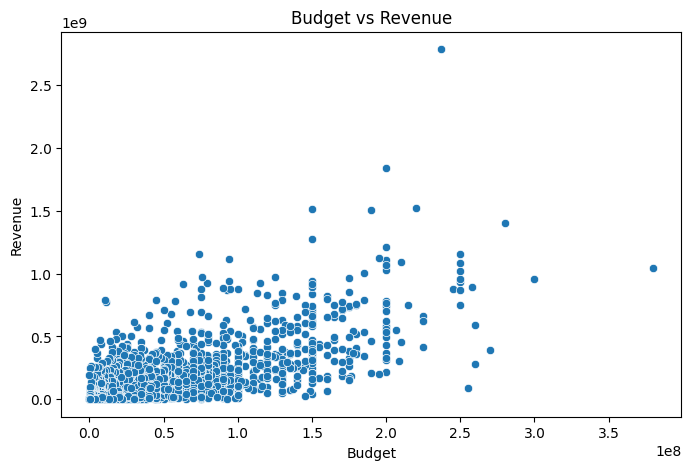

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=movies_clean, x="budget", y="revenue")
plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()

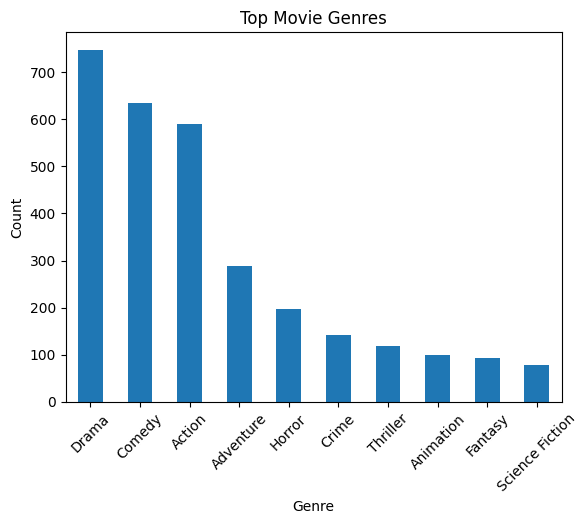

In [18]:
movies_clean["main_genre"].value_counts().head(10).plot(kind="bar")

plt.title("Top Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

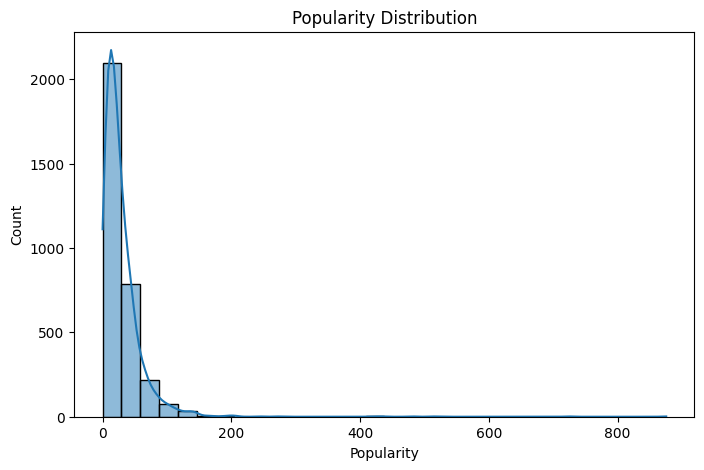

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(movies_clean["popularity"], bins=30, kde=True)

plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

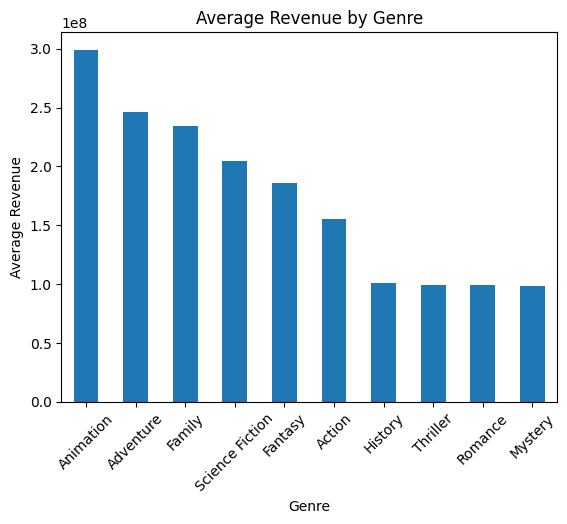

In [20]:
avg_revenue = movies_clean.groupby("main_genre")["revenue"].mean().sort_values(ascending=False).head(10)

avg_revenue.plot(kind="bar")

plt.title("Average Revenue by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.show()

In [21]:
movies_clean[["budget", "revenue", "popularity"]].describe()

,budget,revenue,popularity
count,3.232000e+03,3.232000e+03,3232.000000
mean,4.064456e+07,1.213047e+08,29.042226
std,4.437934e+07,1.862899e+08,36.150742
min,1.000000e+00,5.000000e+00,0.019984
25%,1.050000e+07,1.700000e+07,10.468206
50%,2.500000e+07,5.522308e+07,20.421905
75%,5.500000e+07,1.463434e+08,37.361390
max,3.800000e+08,2.787965e+09,875.581305


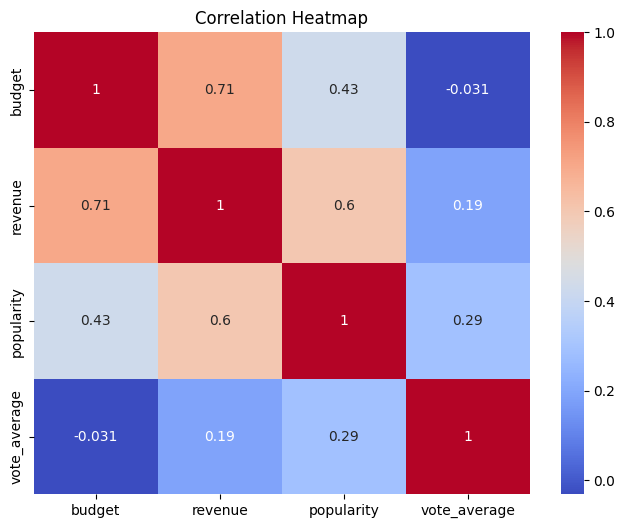

In [22]:
correlation_matrix = movies_clean[
    ["budget", "revenue", "popularity", "vote_average"]
].corr()

correlation_matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [23]:
correlation_matrix = movies_clean[
    ["budget", "revenue", "popularity", "vote_average"]
].corr()

correlation_matrix

,budget,revenue,popularity,vote_average
budget,1.000000,0.705037,0.431938,-0.031333
revenue,0.705037,1.000000,0.602143,0.188128
popularity,0.431938,0.602143,1.000000,0.286992
vote_average,-0.031333,0.188128,0.286992,1.000000


### Average Revenue per Genre

In [24]:
genre_revenue = movies_clean.groupby(
    "main_genre"
)["revenue"].mean().sort_values(ascending=False)

genre_revenue.head(10)

main_genre
Animation          2.989416e+08
Adventure          2.460844e+08
Family             2.340616e+08
Science Fiction    2.047634e+08
Fantasy            1.858356e+08
Action             1.553861e+08
History            1.007775e+08
Thriller           9.904276e+07
Romance            9.892815e+07
Mystery            9.849483e+07
Name: revenue, dtype: float64

In [25]:
top_movies = movies_clean.sort_values(
    by="revenue",
    ascending=False
)[["title", "revenue", "budget"]].head(10)

top_movies

,title,revenue,budget
0,Avatar,2787965087,237000000
25,Titanic,1845034188,200000000
16,The Avengers,1519557910,220000000
28,Jurassic World,1513528810,150000000
44,Furious 7,1506249360,190000000
7,Avengers: Age of Ultron,1405403694,280000000
124,Frozen,1274219009,150000000
31,Iron Man 3,1215439994,200000000
546,Minions,1156730962,74000000
26,Captain America: Civil War,1153304495,250000000


The statistical analysis shows that there is a positive relationship between movie budget and revenue, meaning that movies with larger budgets generally tend to earn more money. However, budget alone does not guarantee financial success.

The correlation analysis also indicates that popularity is positively related to revenue, while vote average has a weaker relationship with commercial performance.

Genre analysis shows that action, adventure, and animation movies tend to generate the highest average revenues, suggesting that genre influences movie profitability.

The popularity distribution is skewed, with most movies having relatively low popularity scores and only a small number achieving very high popularity.

Overall, the results suggest that both financial investment and genre play important roles in determining movie performance and commercial success.

## Exporting Raw Data and Results


In this section, both the cleaned dataset and the analysis results are exported as CSV files. This allows the data and results to be reused, shared, or reviewed without rerunning the entire notebook.

In [26]:
import os

os.makedirs("exports", exist_ok=True)

In [27]:
movies_clean.to_csv("exports/movies_clean.csv", index=False)

In [28]:
movie_sample.to_csv("exports/llm_movie_classifications.csv", index=False)

In [29]:
stats = movies_clean[["budget", "revenue", "popularity"]].describe()

stats.to_csv("exports/statistics_summary.csv")

In [30]:
genre_counts = movies_clean["main_genre"].value_counts()

genre_counts.to_csv("exports/genre_counts.csv")

## Conclusion

This project analyzed movie data to understand the factors that influence movie success, focusing on variables such as budget, revenue, popularity, and genre.

The analysis showed that movies with higher budgets generally tend to generate higher revenues, although there is significant variation, indicating that a large budget does not guarantee success. Genre also plays an important role, with certain genres such as animation and adventure often generating higher average revenues.

The dataset was also found to be highly skewed in terms of popularity, with only a small number of movies achieving very high popularity scores.

Additionally, a local LLM (Ollama) was used to classify movie descriptions into genres. This demonstrated how AI can be integrated into data pipelines to extract insights from unstructured text data.

Overall, the project highlights that movie success is influenced by a combination of financial investment, content type, and audience reception. Future improvements could include using more advanced machine learning models or incorporating additional data sources such as ratings or reviews.